# EDA + Prediction Model + Feature Importance

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, fbeta_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap

In [36]:
multimodal_sports_data = pd.read_csv('data\multimodal_sports_injury_dataset.csv')
display(multimodal_sports_data.query("sport_type == 'Soccer'").shape)
display(multimodal_sports_data.query("sport_type == 'Soccer'").head())

(4837, 29)

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
294,4,87.463504,37.462500,76.081703,7.685010,83.839995,0.428848,116.434703,99.475334,2.760686,...,6.091154,86.712298,670.403658,52.928996,0,1,Soccer,Male,25,20.333866
295,4,59.245371,36.577216,62.682007,4.762600,46.324049,0.387257,58.479094,77.437967,1.127814,...,2.164169,45.285348,313.223976,27.019784,0,2,Soccer,Male,25,20.333866
296,4,81.943337,36.197092,80.925118,6.399375,51.931727,0.483848,318.716362,153.178693,2.192183,...,4.102732,119.252175,605.087683,36.141040,0,3,Soccer,Male,25,20.333866
297,4,93.304239,36.818601,NaN,5.188364,32.971650,0.490228,317.837707,109.090747,1.789226,...,7.359803,134.281955,829.130114,60.693732,0,4,Soccer,Male,25,20.333866
298,4,53.668201,36.775749,73.376115,3.981149,30.595759,0.585591,224.041860,138.717191,1.713544,...,3.195649,35.351091,203.352770,37.205234,0,5,Soccer,Male,25,20.333866


In [37]:
soccer_data = multimodal_sports_data.query("sport_type == 'Soccer'")
# soccer_data = multimodal_sports_data

## EDA

1. DATASET OVERVIEW
Dataset Shape: 4837 rows, 29 columns

Data Types & Missing Values:
                   Data Type  Missing Values  Missing %
heart_rate           float64             107       2.21
hydration_level      float64             121       2.50
sleep_quality        float64             155       3.20
muscle_activity      float64             178       3.68
gait_speed           float64             127       2.63
training_intensity   float64             218       4.51


2. TARGET VARIABLE DISTRIBUTION


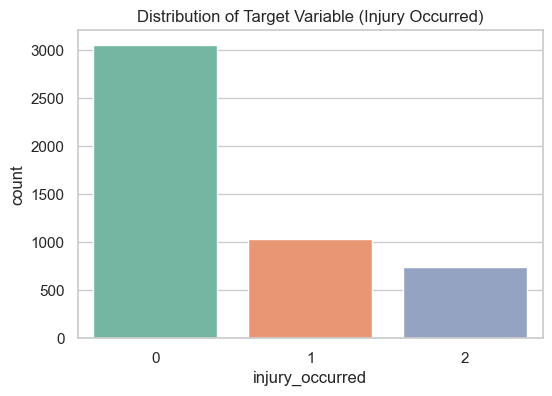

3. FEATURE DISTRIBUTIONS (NUMERICAL)


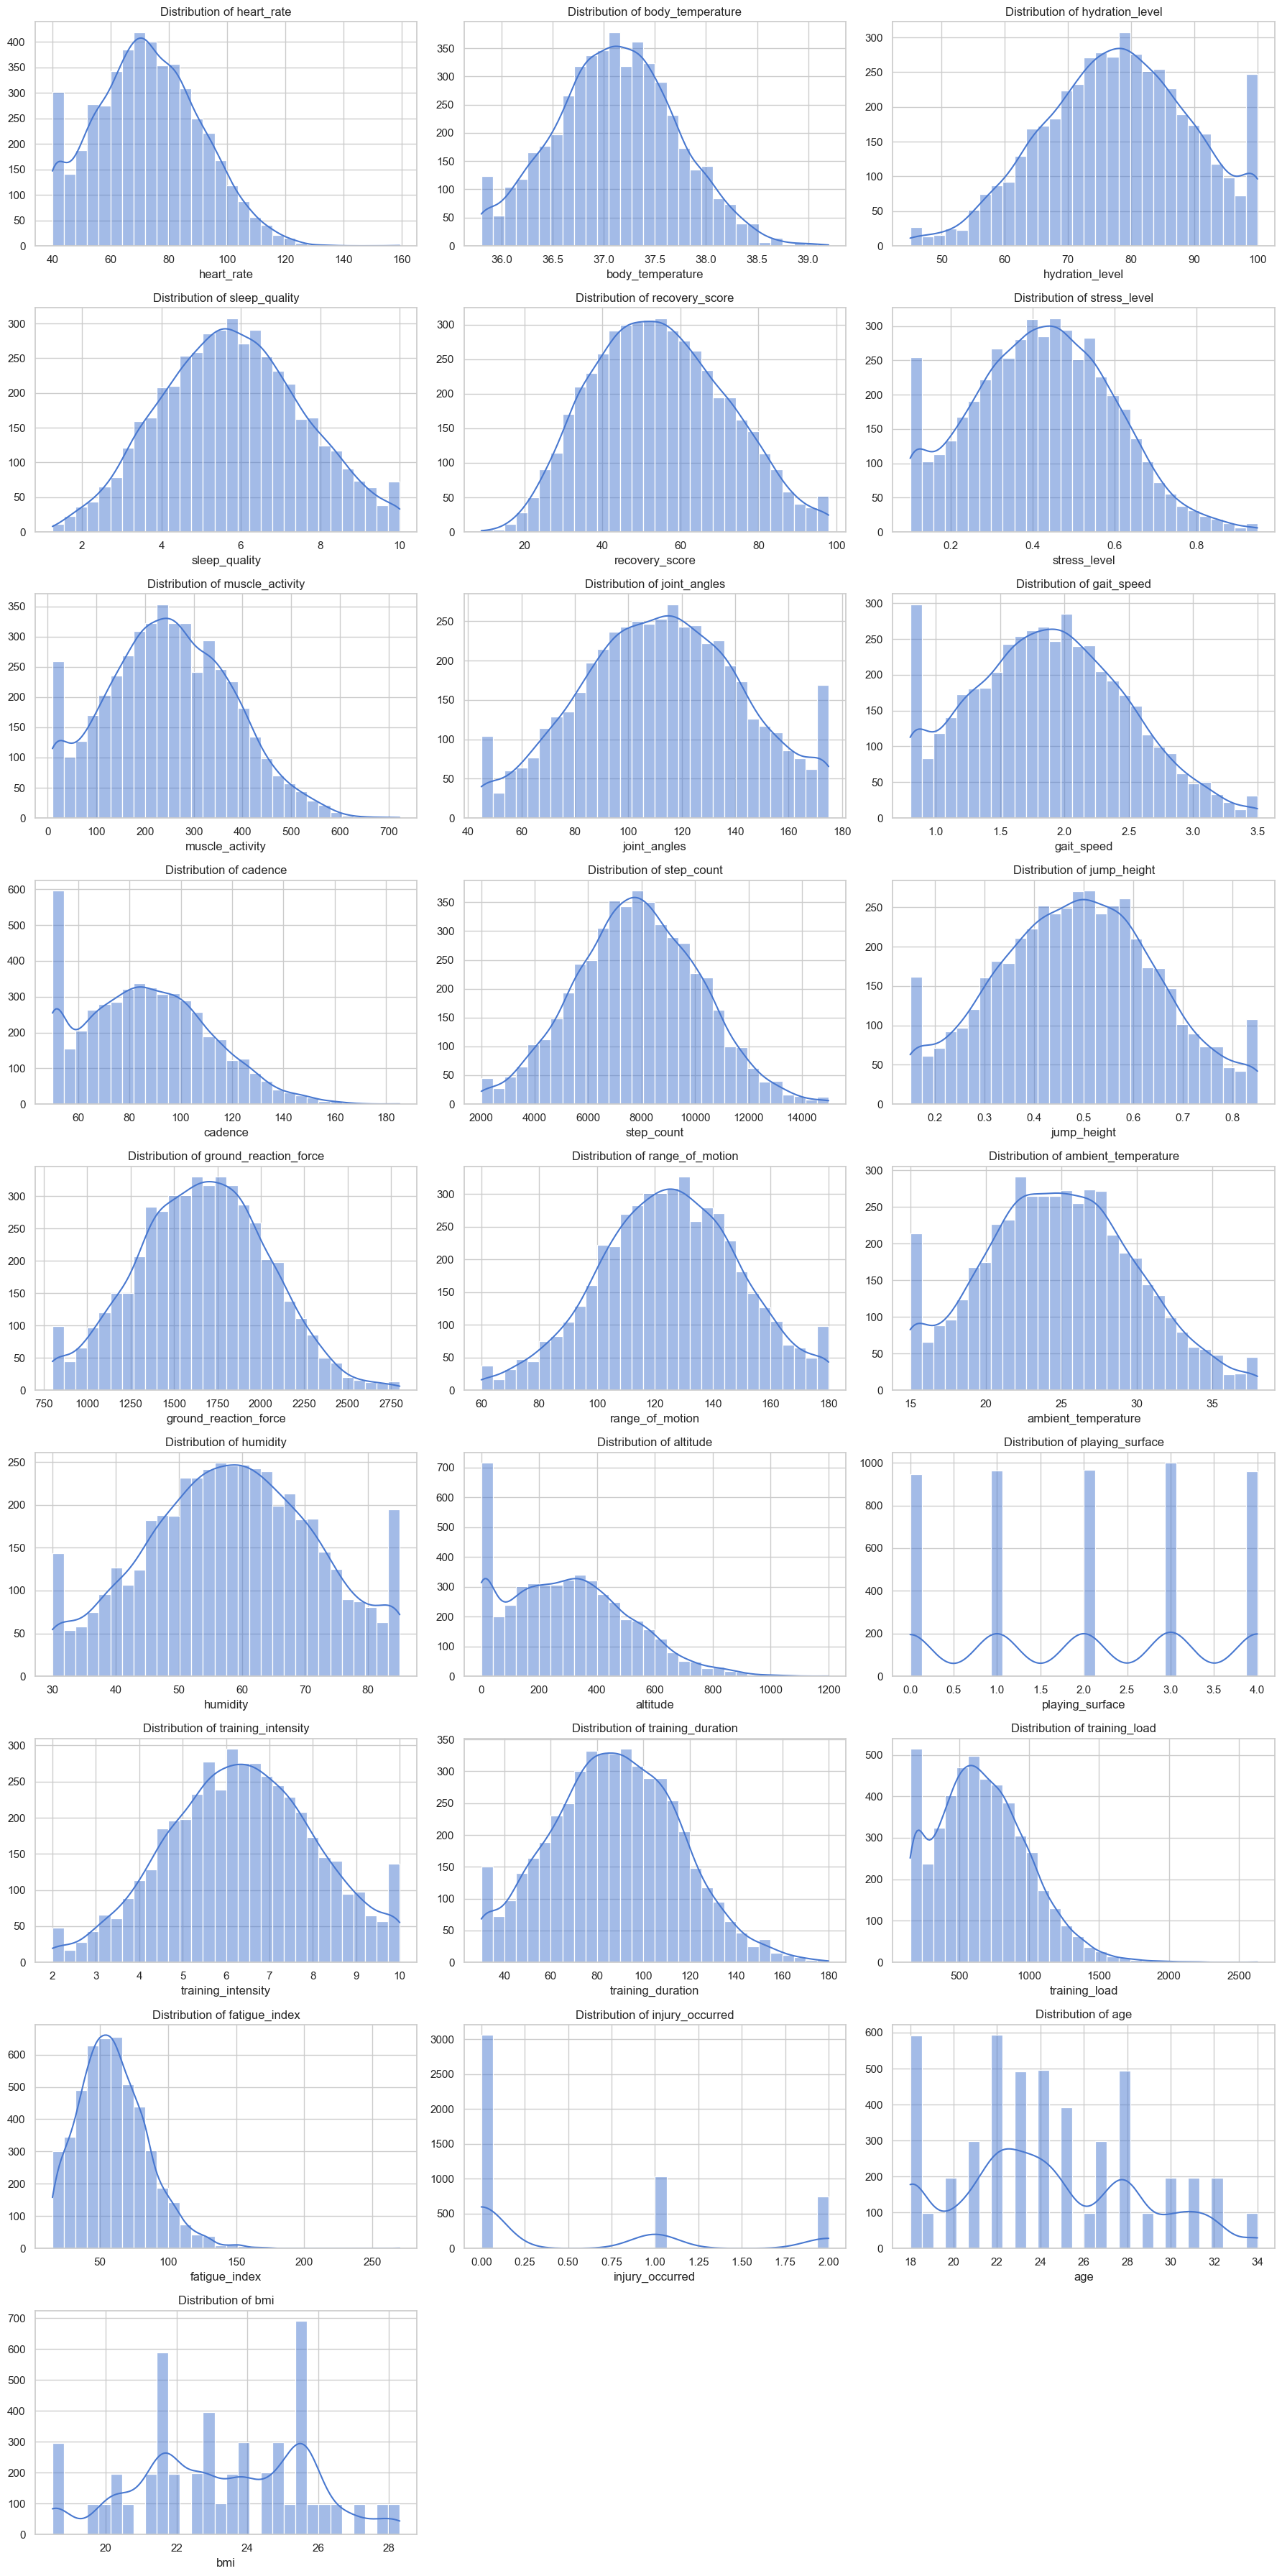

4. OUTLIER DETECTION (BOXPLOTS)


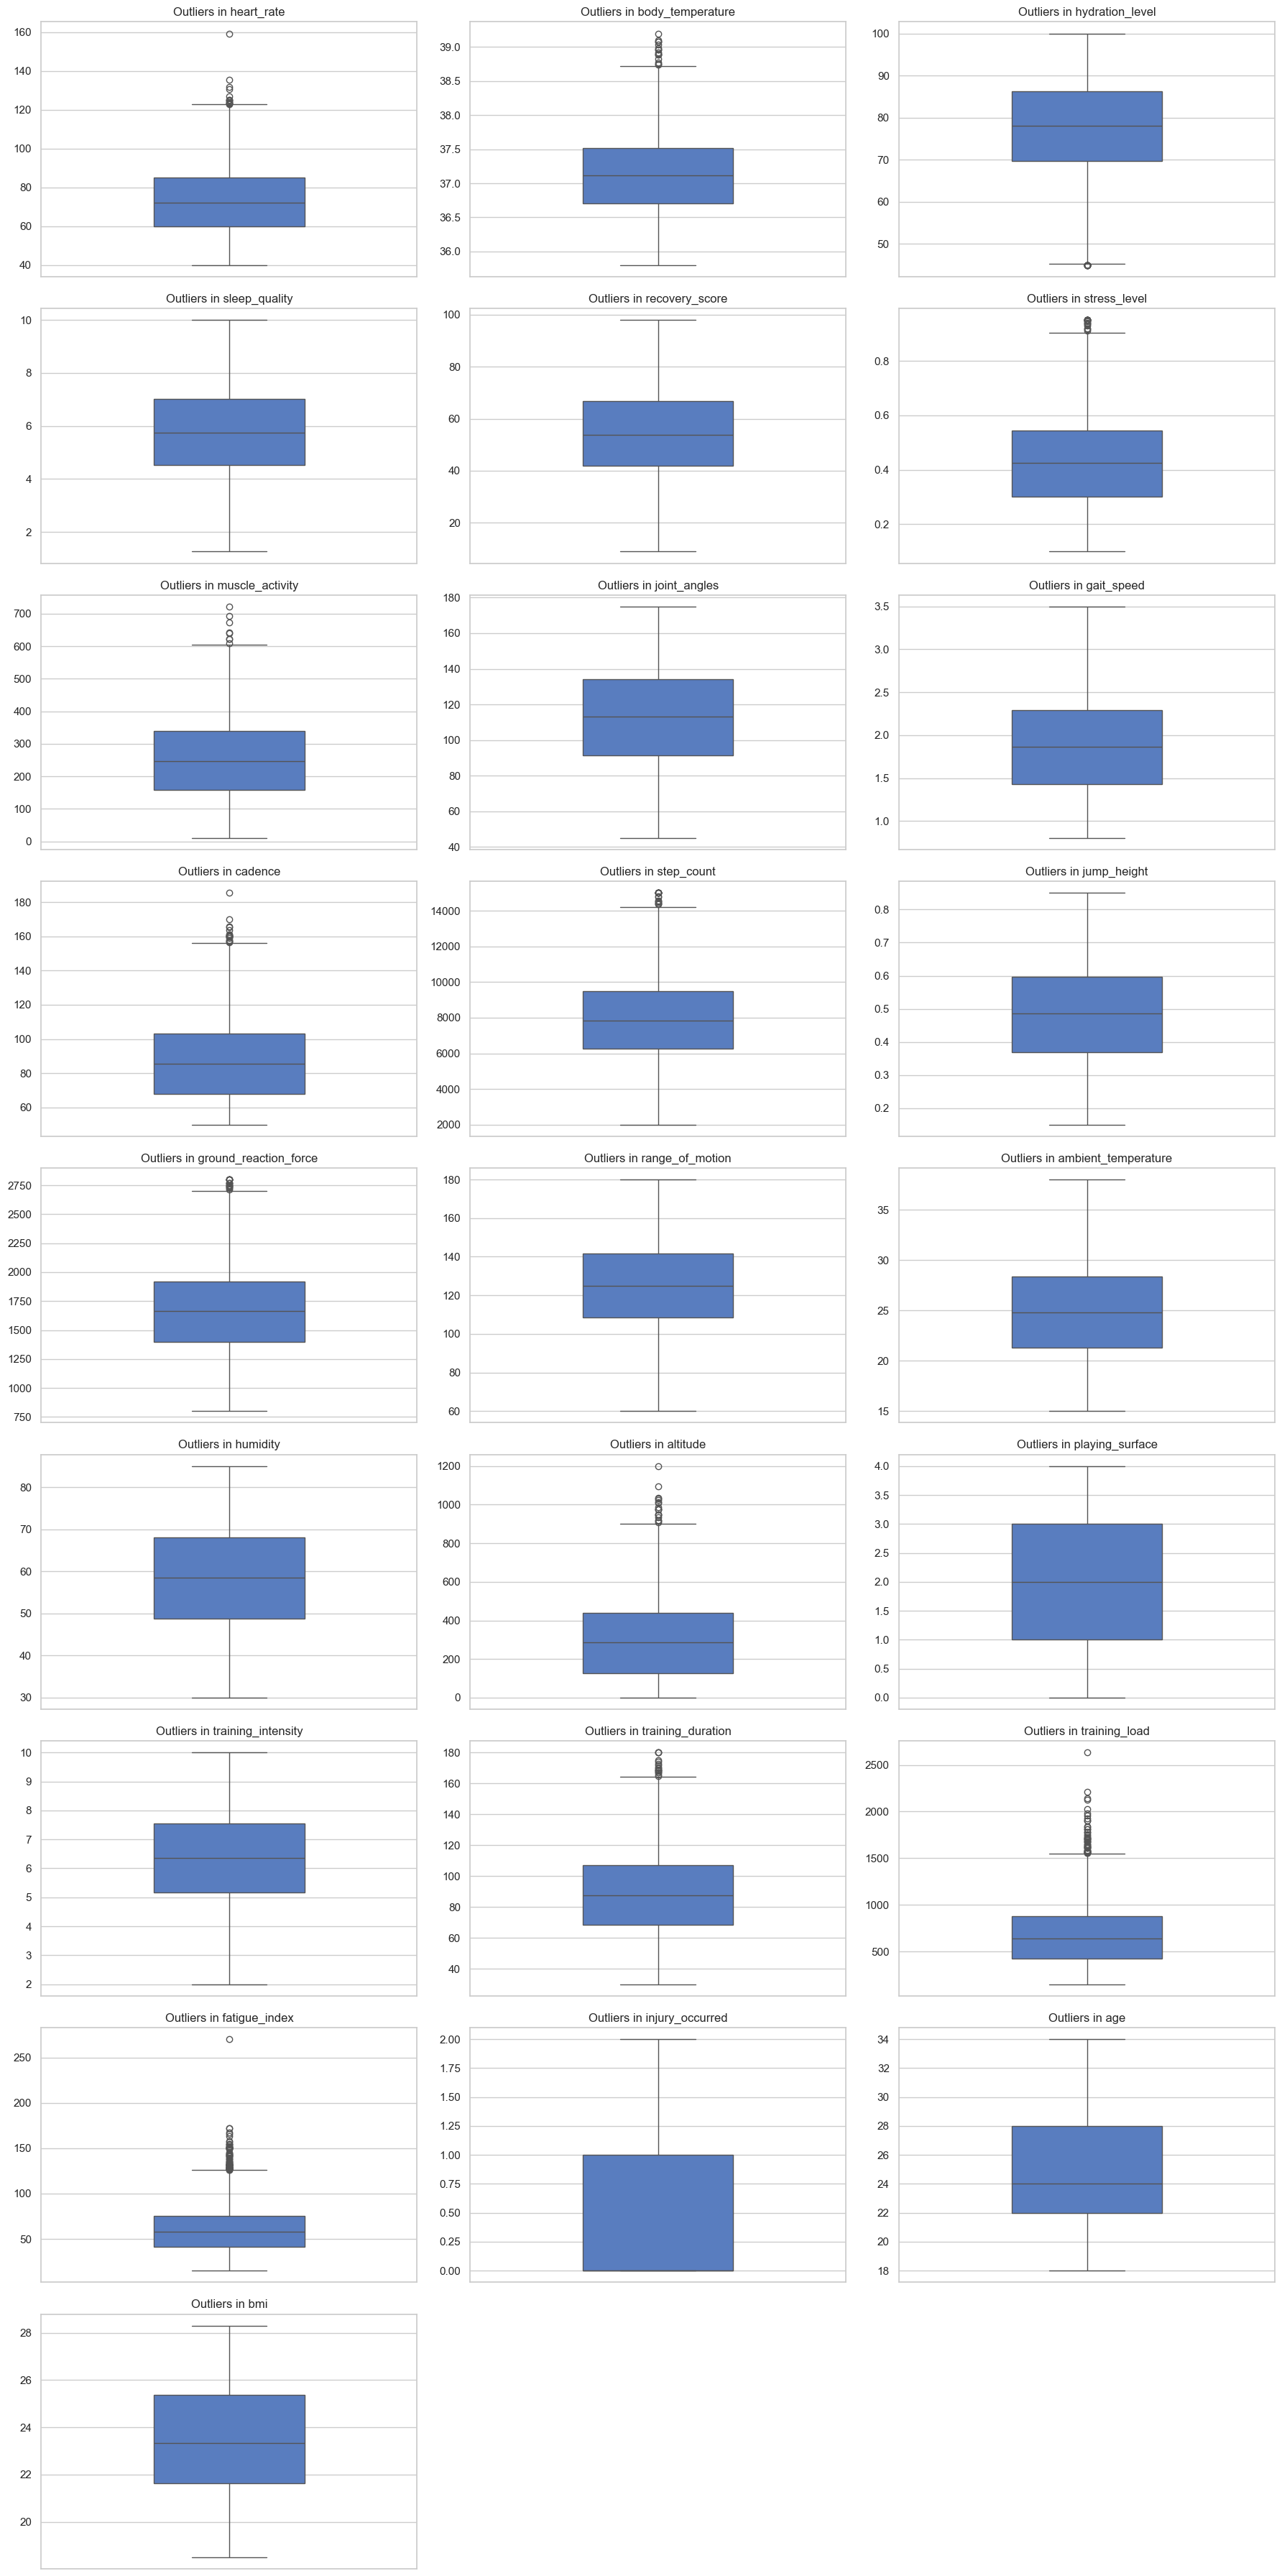

5. CATEGORICAL FEATURE ANALYSIS


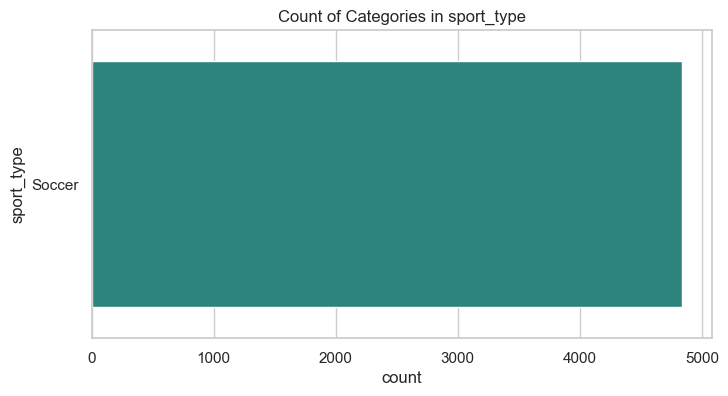

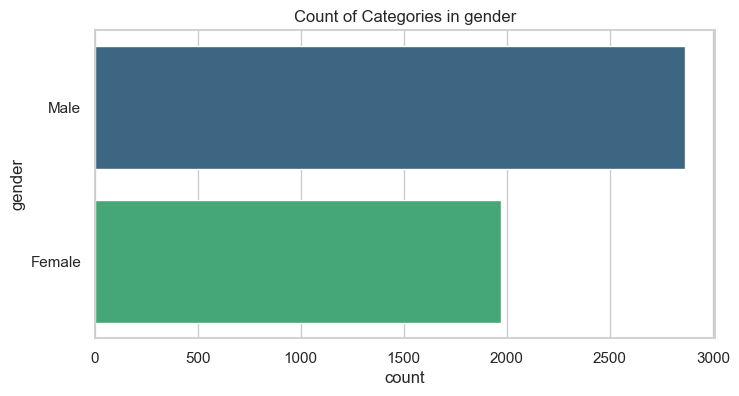

6. MULTIVARIATE ANALYSIS: CORRELATION HEATMAP


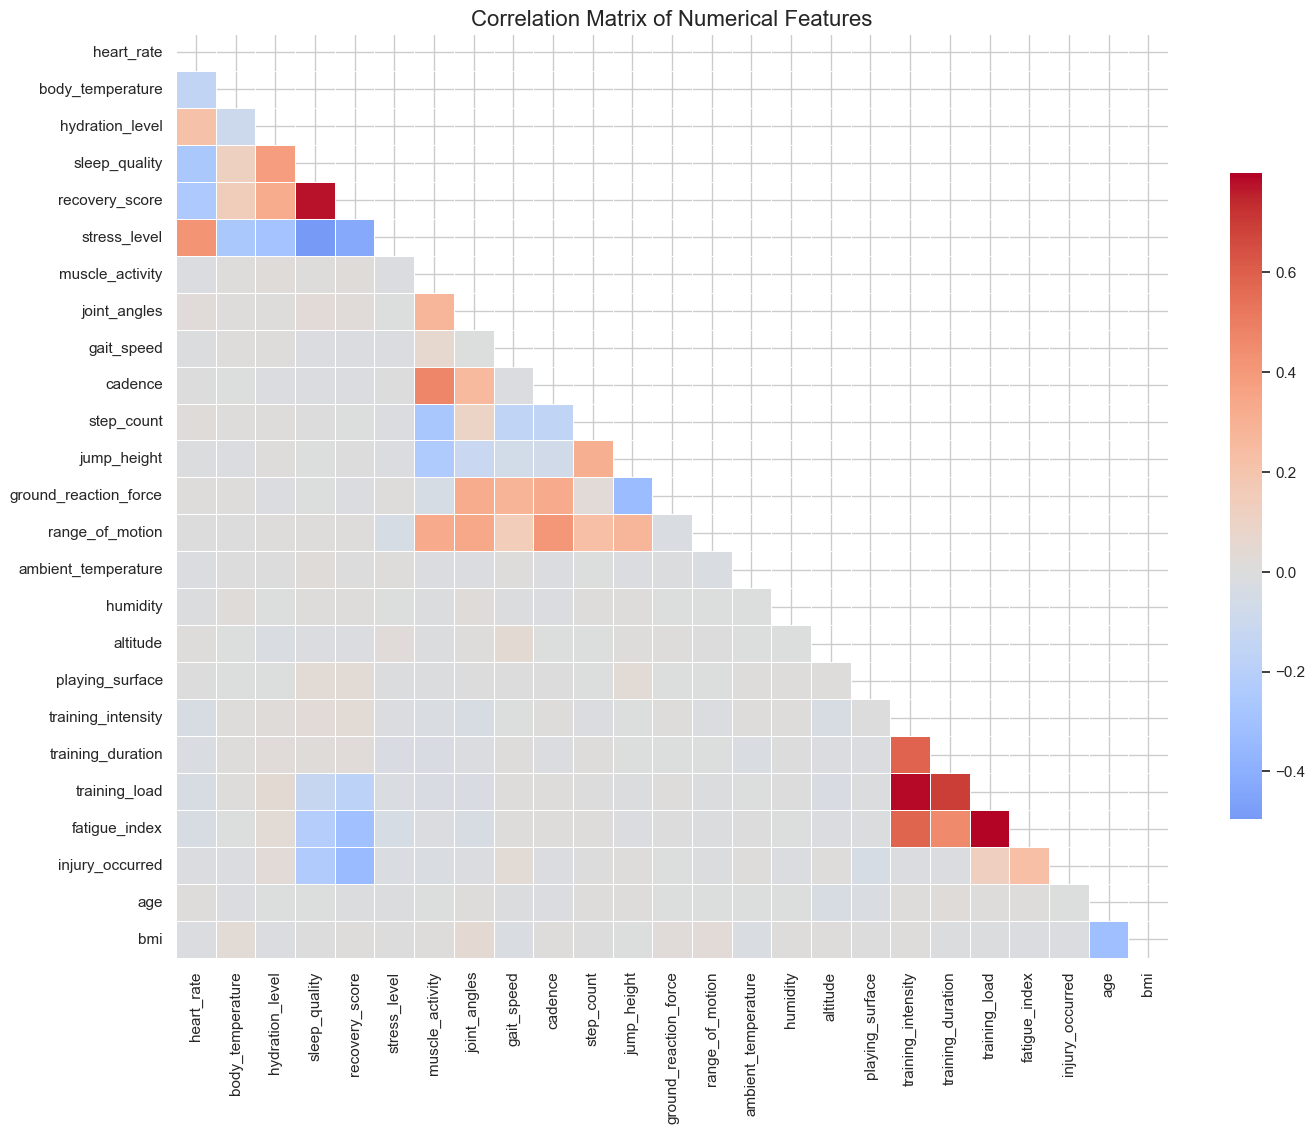

In [38]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set aesthetic parameters for seaborn
sns.set_theme(style="whitegrid", palette="muted")

def perform_comprehensive_eda(df):
    """
    Executes a full EDA pipeline including basic info, distributions, 
    outlier detection, and correlation analysis.
    """
    print("="*50)
    print("1. DATASET OVERVIEW")
    print("="*50)
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    print("Data Types & Missing Values:")
    
    # Calculate missing percentage
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    info_df = pd.DataFrame({'Data Type': df.dtypes, 
                            'Missing Values': missing_data, 
                            'Missing %': missing_percent.round(2)})
    print(info_df[info_df['Missing Values'] > 0])
    print("\n")
    
    # Separate categorical and numerical columns dynamically
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    
    # Remove identifiers from numerical columns for plotting
    for col in ['athlete_id', 'session_id']:
        if col in num_cols: num_cols.remove(col)

    print("="*50)
    print("2. TARGET VARIABLE DISTRIBUTION")
    print("="*50)
    if 'injury_occurred' in df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x='injury_occurred', palette='Set2')
        plt.title('Distribution of Target Variable (Injury Occurred)')
        plt.show()
    else:
        print("Target variable 'injury_occurred' not found.\n")

    print("="*50)
    print("3. FEATURE DISTRIBUTIONS (NUMERICAL)")
    print("="*50)
    # Plotting distributions with KDE (Kernel Density Estimate)
    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_ylabel('')
    
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

    print("="*50)
    print("4. OUTLIER DETECTION (BOXPLOTS)")
    print("="*50)
    # Boxplots are excellent for visualizing IQR and outliers
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i], width=0.4)
        axes[i].set_title(f'Outliers in {col}')
        axes[i].set_ylabel('')
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

    print("="*50)
    print("5. CATEGORICAL FEATURE ANALYSIS")
    print("="*50)
    if cat_cols:
        for col in cat_cols:
            plt.figure(figsize=(8, 4))
            sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
            plt.title(f'Count of Categories in {col}')
            plt.show()

    print("="*50)
    print("6. MULTIVARIATE ANALYSIS: CORRELATION HEATMAP")
    print("="*50)
    # Compute correlation matrix for numerical features
    corr_matrix = df[num_cols].corr()
    
    plt.figure(figsize=(16, 12))
    # Mask the upper triangle for readability
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
                center=0, linewidths=0.5, cbar_kws={"shrink": .7})
    plt.title('Correlation Matrix of Numerical Features', fontsize=16)
    plt.show()

perform_comprehensive_eda(soccer_data)

### EDA outcomes

Feature distribution plots show a ceiling and flooring issue with the wearables that took the data. There are high spikes on the mins or max values. 50+ of the same exact value is highly unlikely to be natural, therefore we look for all features where 50+ players have the same exact count, we make that value NaN and then impute using KNN imputer.

Boxplots show outliers to be removed. However, I am inclined to leave them in as they may be causes for injury. (the one BMI and training load outlier should probably be removed though)

Multicolinearity plot shows that recovery_score and sleep_quality are highly correlated. Training_intensity, training_duration and training_load are all 3 highly correlated.

In [39]:
# 1. Define continuous numerical columns (we exclude categoricals/discrete like 'injury_occurred', 'playing_surface', 'age', 'bmi')
continuous_cols = [
    'heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 
    'recovery_score', 'stress_level', 'muscle_activity', 'joint_angles', 
    'gait_speed', 'cadence', 'step_count', 'jump_height', 'ground_reaction_force', 
    'range_of_motion', 'ambient_temperature', 'humidity', 'altitude', 
    'training_intensity', 'training_duration', 'training_load', 'fatigue_index'
]

# 2. Automatically detect and replace artificial boundary spikes
# In continuous data, an exact min or max repeating 50+ times is an artificial boundary.
spike_threshold = 50 

print("--- Unmasking Artificial Boundaries ---")
for col in continuous_cols:
    col_min = soccer_data[col].min()
    col_max = soccer_data[col].max()
    
    min_count = (soccer_data[col] == col_min).sum()
    max_count = (soccer_data[col] == col_max).sum()
    
    # Check and replace artificial minimums
    if min_count > spike_threshold:
        print(f"{col}: Replaced {min_count} artificial minimums ({col_min}) with NaN.")
        soccer_data[col] = soccer_data[col].replace(col_min, np.nan)
        
    # Check and replace artificial maximums
    if max_count > spike_threshold:
        print(f"{col}: Replaced {max_count} artificial maximums ({col_max}) with NaN.")
        soccer_data[col] = soccer_data[col].replace(col_max, np.nan)

# 3. Apply KNN Imputation to the continuous columns
print("\n--- Applying KNN Imputation ---")
# Using k=5 neighbors is a standard baseline that balances local smoothing without over-averaging
imputer = KNNImputer(n_neighbors=5, weights='uniform')

# Fit and transform the data, then assign it back to the dataframe
soccer_data[continuous_cols] = imputer.fit_transform(soccer_data[continuous_cols])

print("\nImputation complete! Total NaNs remaining in continuous columns:", 
      soccer_data[continuous_cols].isnull().sum().sum())

--- Unmasking Artificial Boundaries ---
heart_rate: Replaced 181 artificial minimums (40.0) with NaN.
body_temperature: Replaced 79 artificial minimums (35.8) with NaN.
hydration_level: Replaced 190 artificial maximums (100.0) with NaN.
sleep_quality: Replaced 56 artificial maximums (10.0) with NaN.
stress_level: Replaced 174 artificial minimums (0.1) with NaN.
muscle_activity: Replaced 179 artificial minimums (10.0) with NaN.
joint_angles: Replaced 78 artificial minimums (45.0) with NaN.
joint_angles: Replaced 120 artificial maximums (175.0) with NaN.
gait_speed: Replaced 220 artificial minimums (0.8) with NaN.
cadence: Replaced 439 artificial minimums (50.0) with NaN.
jump_height: Replaced 107 artificial minimums (0.15) with NaN.
jump_height: Replaced 78 artificial maximums (0.85) with NaN.
ground_reaction_force: Replaced 68 artificial minimums (800.0) with NaN.
range_of_motion: Replaced 72 artificial maximums (180.0) with NaN.
ambient_temperature: Replaced 157 artificial minimums (1

In [40]:
# perform_comprehensive_eda(soccer_data)

In [41]:
# ---------------------------------------------------------
# 1. LOG TRANSFORM SKEWED FEATURES
# ---------------------------------------------------------
# We exclude 'altitude' here because we are categorizing it instead
skewed_cols = ['training_load', 'fatigue_index']

print("Log-transforming skewed features...")
for col in skewed_cols:
    # np.log1p adds 1 to avoid taking the log of 0, which is undefined
    soccer_data[col] = np.log1p(soccer_data[col])


# ---------------------------------------------------------
# 2. CATEGORIZE THE ALTITUDE FEATURE
# ---------------------------------------------------------
print("Categorizing altitude...")
# Define the bins (thresholds) and their corresponding labels
# Adjust these bin edges based on specific sporting thresholds if necessary
bins = [-np.inf, 250, 1000, np.inf] 
labels = ['Sea Level', 'Moderate Altitude', 'High Altitude']

# Create the new categorical column
soccer_data['altitude_category'] = pd.cut(soccer_data['altitude'], bins=bins, labels=labels)

# Convert the text categories into numeric binary columns (One-Hot Encoding)
soccer_data = pd.get_dummies(soccer_data, columns=['altitude_category'], drop_first=False)

# Since we categorized it, we drop the original continuous 'altitude' column
soccer_data = soccer_data.drop('altitude', axis=1)

# Remove 'altitude' from our continuous_cols list so the scaler doesn't look for it
if 'altitude' in continuous_cols:
    continuous_cols.remove('altitude')

# ---------------------------------------------------------
# 3. SCALE THE DATA WITH ROBUSTSCALER
# ---------------------------------------------------------
print("Scaling continuous features using RobustScaler...")
scaler = RobustScaler()

# Apply the scaler ONLY to the continuous columns 
# (This skips our categorical targets, one-hot encoded columns, and identifiers)
soccer_data[continuous_cols] = scaler.fit_transform(soccer_data[continuous_cols])

print("\nPreprocessing complete! Here is a peek at the scaled data:")
soccer_data[continuous_cols].head()

Log-transforming skewed features...
Categorizing altitude...
Scaling continuous features using RobustScaler...

Preprocessing complete! Here is a peek at the scaled data:


,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,cadence,step_count,jump_height,ground_reaction_force,range_of_motion,ambient_temperature,humidity,training_intensity,training_duration,training_load,fatigue_index
294,0.635303,0.435687,-0.086613,0.822579,1.202092,-0.022657,-0.838008,-0.323837,1.131878,-1.114062,0.668436,-0.736861,1.269133,-1.076256,-1.441407,0.401539,-0.100051,-0.029299,0.047521,-0.153533
295,-0.612217,-0.694837,-0.991744,-0.412682,-0.304888,-0.207394,-1.195925,-0.872959,-0.986231,-0.977168,0.825788,0.357591,-0.991659,-0.786365,-1.138525,0.819132,-1.815148,-1.130968,-1.082410,-1.298142
296,0.391257,-1.180263,0.240553,0.279160,-0.079633,0.221633,0.411222,1.014330,0.394435,0.331149,0.117390,-0.260660,0.000000,0.931197,-0.437193,-0.065943,-0.968488,0.836035,-0.104790,-0.805495
297,0.893521,-0.386585,-0.125895,-0.232718,-0.841241,0.249971,0.405796,-0.084243,-0.128268,1.069472,0.596004,0.040590,0.571257,0.979992,0.616924,0.026800,0.454026,1.235723,0.363333,0.081617
298,-0.858783,-0.441307,-0.269372,-0.742990,-0.936679,0.673544,-0.173459,0.653982,-0.226441,0.671525,0.650952,-0.306893,0.202110,0.261134,0.959635,0.266622,-1.364653,-1.395150,-1.722717,-0.756110


In [42]:
# List of redundant features to drop based on correlation analysis
features_to_drop = [
    'training_intensity', 
    'training_duration',
    'recovery_score'
]

print(f"Dataset shape before dropping: {soccer_data.shape}")

# Drop the columns
soccer_data = soccer_data.drop(columns=features_to_drop)

print(f"Dataset shape after dropping: {soccer_data.shape}")
print(f"Dropped features: {features_to_drop}")

Dataset shape before dropping: (4837, 31)
Dataset shape after dropping: (4837, 28)
Dropped features: ['training_intensity', 'training_duration', 'recovery_score']


## Baseline Model

### Feature Engineering

In [ ]:
# 1. Sort the data chronologically per player (CRITICAL for rolling windows)
soccer_data = soccer_data.sort_values(by=['athlete_id', 'session_id'])

# 2. Define the exact window sizes
acute_window = 7
chronic_window = 28

# 3. Calculate Acute and Chronic Loads per player (Strict Windows)
soccer_data['acute_load'] = soccer_data.groupby('athlete_id')['training_load'].transform(
    lambda x: x.rolling(window=acute_window).mean()
)

soccer_data['chronic_load'] = soccer_data.groupby('athlete_id')['training_load'].transform(
    lambda x: x.rolling(window=chronic_window).mean()
)

# 4. Calculate the ACWR
soccer_data['ACWR'] = soccer_data['acute_load'] / soccer_data['chronic_load']

# 5. Handle potential divisions by zero
soccer_data['ACWR'] = soccer_data['ACWR'].replace([np.inf, -np.inf], np.nan)

# 6. OVERWRITE THE BURN-IN PERIOD: 
# Replace all the NaNs from the first 27 sessions with a neutral 1.0 baseline
soccer_data['ACWR'] = soccer_data['ACWR'].fillna(1.0)

# 7. Clean up: Drop the intermediate load columns to prevent multicollinearity 
# in the ML model, keeping only our powerful new ACWR feature
soccer_data = soccer_data.drop(columns=['acute_load', 'chronic_load'])

print(f"Final dataset shape: {soccer_data.shape}")
print("\nFirst 35 rows for Athlete 4 showing the transition from burn-in to active ACWR:")
print(soccer_data[['athlete_id', 'session_id', 'training_load', 'ACWR']].head(35))

Final dataset shape: (4837, 29)

First 35 rows for Athlete 4 showing the transition from burn-in to active ACWR:
     athlete_id  session_id  training_load      ACWR
294           4           1       0.047521  1.000000
295           4           2      -1.082410  1.000000
296           4           3      -0.104790  1.000000
297           4           4       0.363333  1.000000
298           4           5      -1.722717  1.000000
299           4           6       0.674420  1.000000
300           4           7       1.109081  1.000000
301           4           8       0.554991  1.000000
302           4           9       0.849743  1.000000
303           4          10      -1.842888  1.000000
304           4          11      -0.611406  1.000000
305           4          12      -0.389881  1.000000
306           4          13       0.579460  1.000000
307           4          14       0.297324  1.000000
308           4          15       0.111801  1.000000
309           4          16      -0.408

In [44]:
warnings.filterwarnings('ignore')

# ==========================================
# 1. FINAL DATA PREP & BINARY MAPPING
# ==========================================
print("Cleaning data and mapping target to binary classes...")

# A. Drop identifiers and constants that have no predictive value
cols_to_drop = ['athlete_id', 'session_id', 'sport_type']
soccer_data = soccer_data.drop(columns=[c for c in cols_to_drop if c in soccer_data.columns])

# B. Encode 'gender' into numerical values (Male -> 1, Female -> 0)
if 'gender' in soccer_data.columns and soccer_data['gender'].dtype == 'str':
    le = LabelEncoder()
    soccer_data['gender'] = le.fit_transform(soccer_data['gender'])

# C. Map target: 0 (Healthy) and 1 (Low Risk) become 0; 2 (High Risk) becomes 1
soccer_data['injury_binary'] = soccer_data['injury_occurred'].apply(lambda x: 1 if x == 2 else 0)

# D. Separate features (X) and target (y)
X = soccer_data.drop(['injury_occurred', 'injury_binary'], axis=1)
y = soccer_data['injury_binary']

print(f"New Class Distribution:\n{y.value_counts()}")


# ==========================================
# 2. TRAIN/TEST SPLIT
# ==========================================
# Split FIRST to prevent data leakage of synthetic SMOTE data into the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ==========================================
# 3. APPLY SMOTE (TRAIN DATA ONLY)
# ==========================================
print("\nApplying SMOTE to balance the training data...")
smote = SMOTE(random_state=42)

# Fit and resample ONLY the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Training Data Distribution BEFORE SMOTE:\n{y_train.value_counts()}")
print(f"Training Data Distribution AFTER SMOTE:\n{y_train_smote.value_counts()}")


# ==========================================
# 4. OPTUNA OPTIMIZATION (FOR F2-SCORE)
# ==========================================
def objective(trial):
    param = {
        'objective': 'binary:logistic', 
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'random_state': 42
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f2_scores = []

    # Train using the SMOTE balanced data
    for train_idx, val_idx in skf.split(X_train_smote, y_train_smote):
        X_tr, X_val = X_train_smote.iloc[train_idx], X_train_smote.iloc[val_idx]
        y_tr, y_val = y_train_smote.iloc[train_idx], y_train_smote.iloc[val_idx]

        model = xgb.XGBClassifier(**param)
        model.fit(X_tr, y_tr, verbose=False)

        preds = model.predict(X_val)
        
        # Optimize for F2 Score (Heavily penalizing False Negatives)
        f2 = fbeta_score(y_val, preds, beta=2)
        f2_scores.append(f2)

    return np.mean(f2_scores)

print("\nStarting Optuna tuning for maximum F2-Score...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)


# ==========================================
# 5. TRAIN & EVALUATE FINAL MODEL
# ==========================================
print("\nTraining final model...")
best_params = study.best_trial.params
best_params['objective'] = 'binary:logistic'
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42

final_xgb_model = xgb.XGBClassifier(**best_params)

# Train on the FULL SMOTE-balanced training set
final_xgb_model.fit(X_train_smote, y_train_smote)

# Predict on the UNTOUCHED test set to see real-world performance
y_pred = final_xgb_model.predict(X_test)

print("\n" + "="*50)
print("FINAL BINARY CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Healthy Baseline (0)', 'At Risk (1)']))

print("\nCONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, 
                   index=['Actual Healthy (0)', 'Actual Risk (1)'], 
                   columns=['Predicted Healthy (0)', 'Predicted Risk (1)']))

Cleaning data and mapping target to binary classes...
New Class Distribution:
injury_binary
0    4095
1     742
Name: count, dtype: int64

Applying SMOTE to balance the training data...


[I 2026-05-16 22:35:11,966] A new study created in memory with name: no-name-ce0a4a5d-528b-4f85-be0f-47f12b8e9245


Training Data Distribution BEFORE SMOTE:
injury_binary
0    3275
1     594
Name: count, dtype: int64
Training Data Distribution AFTER SMOTE:
injury_binary
0    3275
1    3275
Name: count, dtype: int64

Starting Optuna tuning for maximum F2-Score...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-16 22:35:20,179] Trial 0 finished with value: 0.8885980650493782 and parameters: {'lambda': 2.611088273080617e-06, 'alpha': 0.00846290979218248, 'colsample_bytree': 0.9158069430925091, 'subsample': 0.616026720299881, 'learning_rate': 0.002931108555578811, 'max_depth': 9, 'min_child_weight': 2, 'n_estimators': 815}. Best is trial 0 with value: 0.8885980650493782.
[I 2026-05-16 22:35:20,523] Trial 1 finished with value: 0.8194251124025803 and parameters: {'lambda': 3.647221311862237e-08, 'alpha': 7.680984538434187e-08, 'colsample_bytree': 0.9815997807647079, 'subsample': 0.8934982833968523, 'learning_rate': 0.015939256914314453, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 122}. Best is trial 0 with value: 0.8885980650493782.
[I 2026-05-16 22:35:21,482] Trial 2 finished with value: 0.8256565046620219 and parameters: {'lambda': 4.70930609156701e-07, 'alpha': 0.008023575380134656, 'colsample_bytree': 0.937843848291096, 'subsample': 0.7722391181254769, 'learning_rate': 

Note: Recall tells us that the model caught so much % of all the injuries (or whatever we are predicting) but precision tells us that we were only right so much % of the time.

Balancing the data using SMOTE increase accuracy by a lot.

F2-Score (which heavily penalizes missed injuries) allowed the model become slightly over-cautious. It is now catching 51% of all injuries, but at a cost to precision in that each time it predicts an injury it will be right 45% of the time.

This prediction is stating that there is a high risk that a player will get injured in the next 7 days. The target is saying that 1 (yes there was an injury in the next 7 days)

No temporal aspect. We cannot see cummulative effects which is NB!

## SHAP Analysis

Calculating SHAP values... (This might take a few seconds)

--- SHAP Summary Plot (Impact & Direction) ---


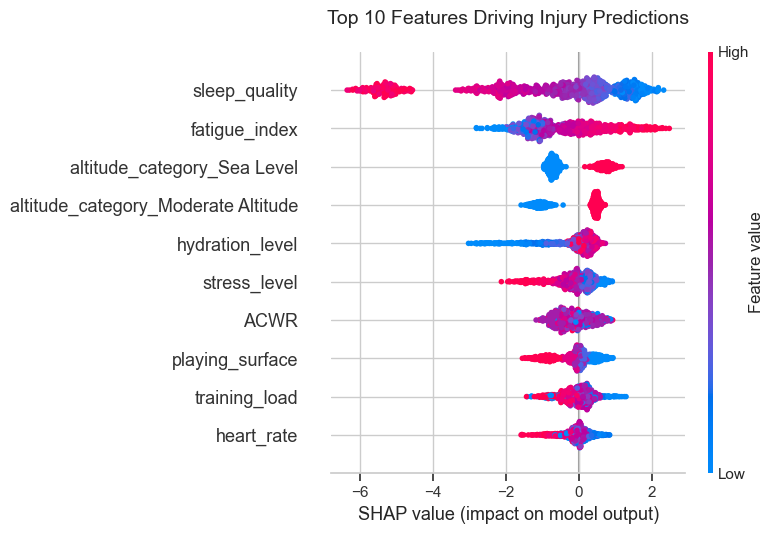


--- SHAP Bar Plot (Average Absolute Impact) ---


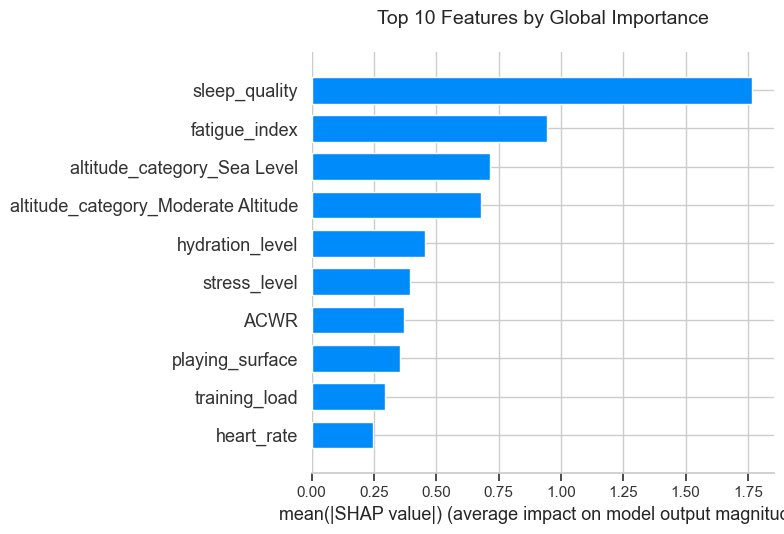

In [45]:
# 1. Initialize JS visualization (helpful if running in Jupyter Notebook/Colab)
shap.initjs()

print("Calculating SHAP values... (This might take a few seconds)")

# 2. Create the Tree Explainer specifically for our XGBoost model
explainer = shap.TreeExplainer(final_xgb_model)

# 3. Calculate SHAP values for the test set
# We use the test set (X_test) so we see how the model makes decisions on unseen data
shap_values = explainer.shap_values(X_test)

# 4. Plot the top 10 most important features (Standard Summary Dot Plot)
print("\n--- SHAP Summary Plot (Impact & Direction) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("Top 10 Features Driving Injury Predictions", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 5. Plot the top 10 most important features (Simple Bar Plot)
print("\n--- SHAP Bar Plot (Average Absolute Impact) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False)
plt.title("Top 10 Features by Global Importance", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

What SHAP is showing us:
- High levels of sleep = more healthy = less likely to get injured
- High fatigue index = more likely to get injured = rest is important
- Altitude at sea level sees more injuries than the other two (but sea level altitude is over indexed so maybe not that wow)
- Moderate altitude bares an impact on injuries too (could be wow maybe)

What doesn't make sense:
- More stress = healthier? Sus
- More hydraion = more likely to get injured (no make sense)

Why the weird anomalies?

- Imputation Artifacts: We imputed missing data earlier. If a lot of healthy players had missing hydration data, our imputation might have mathematically linked lower numbers to health.

- SMOTE Artifacts: SMOTE generated synthetic "At Risk" players. Sometimes, the algorithm connects random noise in the minority class to the target variable.

- Kaggle Dataset Realities: Possible synthetic data showing weird patterns